# Atividade Opcional — 5G Dataset Challenge

**Disciplina:** PGC308A — Inteligência Artificial
**Tipo de atividade:** Desafio aberto (*open-ended*), adaptado da *Hackathon SMARTNESS / 5G Dataset Challenge* (SBRC 2023)

---

## Contexto

O avanço das redes 5G no Brasil trouxe consigo uma quantidade enorme de dados sobre o comportamento da rede móvel e da experiência de uso de aplicações sensíveis a desempenho, como o streaming de vídeo adaptativo. Este notebook explora os conjuntos de dados disponibilizados pelo repositório [`hackathon5G`](https://github.com/intrig-unicamp/hackathon5G) (INTRIG/UNICAMP), construídos a partir de testes de campo com um *Samsung S21 5G* na cidade de São Paulo, na operadora Claro.

Como esta é uma atividade do tipo desafio — **sem uma única resposta correta** — este notebook apresenta uma linha de solução possível para os quatro problemas propostos, com foco em:

1. Carregar e explorar os três conjuntos de dados (`g-nettrack-pro`, `mosaico` e `youtube-qoe`);
2. Realizar o enriquecimento de dados combinando as bases de rede móvel com a base auxiliar do Mosaico/Anatel;
3. Desenvolver um modelo (estatístico/ML) para cada uma das quatro atividades propostas (A, B, C e D);
4. Discutir os resultados, limitações e *insights* obtidos.

## Conjuntos de dados utilizados

| Dataset | Descrição | Uso neste notebook |
|---|---|---|
| `g-nettrack-pro` | Métricas de rede móvel (RSRP, RSRQ, SNR, CQI, tecnologia, coordenadas GPS, célula servidora, etc.), coletadas com o app G-NetTrack Pro em 12 sessões (a pé, de carro, metrô, indoor) | Base principal para as Atividades A, B e D |
| `mosaico` (Anatel) | Cadastro de Estações Rádio Base (ERBs) licenciadas no Brasil — localização, tecnologia, frequência, azimute, potência | Enriquecimento de dados (antenas próximas) nas Atividades A, C e D |
| `youtube-qoe` | Métricas de streaming de vídeo do YouTube (resolução, *buffer health*, alertas de QoE, banda estimada), capturadas via PCAPdroid | Base principal da Atividade C |

## Estrutura do notebook
1. Configuração do ambiente e download dos dados
2. Carregamento e Análise Exploratória de Dados (AED)
3. Atividade A — Predição de Qualidade de Sinal
4. Atividade B — Predição do Tipo de Mobilidade
5. Atividade C — Predição de QoE de Streaming de Vídeo
6. Atividade D — Inferência da Célula/Estação Base Conectada
7. Conclusão, limitações e trabalhos futuros


## 1. Configuração do ambiente

A célula abaixo baixa o repositório de dados (`hackathon5G`) caso ele ainda não exista localmente, e instala as bibliotecas necessárias. Seguimos a recomendação do próprio repositório de baixar os dados via `git clone` em tempo de execução, em vez de re-distribuir os arquivos junto da submissão.


In [1]:
# Instalação de dependências (silenciosa se já estiverem instaladas)
import sys, subprocess
def pip_install(pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "--break-system-packages", *pkgs])

pip_install(["pandas", "numpy", "scikit-learn", "matplotlib", "seaborn"])


In [2]:
import os

REPO_DIR = "hackathon5G"
if not os.path.isdir(REPO_DIR):
    print("Clonando o repositório de dados (hackathon5G)...")
    os.system(f"git clone --depth=1 https://github.com/intrig-unicamp/hackathon5G.git {REPO_DIR}")
else:
    print("Repositório já presente, pulando o clone.")


Repositório já presente, pulando o clone.


In [3]:
import glob
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    adjusted_rand_score, silhouette_score,
    accuracy_score, balanced_accuracy_score, confusion_matrix,
)
from sklearn.neighbors import BallTree

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 50)

RNG = 42
GNETTRACK_DIR = os.path.join(REPO_DIR, "datasets", "g-nettrack-pro")
MOSAICO_DIR = os.path.join(REPO_DIR, "datasets", "mosaico")
YOUTUBE_QOE_DIR = os.path.join(REPO_DIR, "datasets", "youtube-qoe")


## 2. Carregamento e Análise Exploratória de Dados (AED)

### 2.1 Dados de rede móvel (`g-nettrack-pro`)

O `g-nettrack-pro` contém 12 arquivos `.txt` (separados por TAB), um por sessão de coleta. Cada sessão tem no nome um indício do tipo de deslocamento realizado (a pé na Av. Paulista, de carro, metrô ou parado em ambiente fechado), o que usaremos **somente como rótulo de validação** na Atividade B (clusterização não supervisionada).

Alguns arquivos trazem, em certas linhas, colunas extras de células vizinhas que não aparecem no cabeçalho declarado (o G-NetTrack Pro adiciona grupos repetidos quando detecta mais células vizinhas que o padrão). Por isso usamos um *parser* manual, que mantém apenas as colunas nomeadas no cabeçalho e descarta o excedente — preservando todas as métricas relevantes para a análise.


In [4]:
NUMERIC_COLS = [
    "Longitude", "Latitude", "Speed", "Level", "Qual", "SNR", "CQI", "LTERSSI",
    "ARFCN", "DL_bitrate", "UL_bitrate", "Altitude", "Accuracy", "Distance",
    "Bearing", "CellID", "LAC",
]

def scenario_from_filename(fname):
    '''Extrai um rotulo de mobilidade a partir do nome do arquivo (usado so para
    VALIDAR o agrupamento nao supervisionado da Atividade B, nunca como feature).'''
    base = os.path.basename(fname)
    if "subway" in base:
        return "metro"
    if "walking" in base:
        return "pedestre"
    if "driving" in base:
        return "veiculo"
    if "indoor" in base:
        return "indoor"
    return "outro"  # sessao sem rotulo de mobilidade no nome (usada na Atividade C)


def load_gnettrack_file(path):
    with open(path, "r", encoding="utf-8", errors="replace") as fh:
        header = fh.readline().rstrip("\n").rstrip("\r").split("\t")
        ncols = len(header)
        rows = []
        for line in fh:
            line = line.rstrip("\n").rstrip("\r")
            if not line:
                continue
            fields = line.split("\t")
            if len(fields) < ncols:
                fields = fields + [np.nan] * (ncols - len(fields))
            elif len(fields) > ncols:
                fields = fields[:ncols]
            rows.append(fields)

    df = pd.DataFrame(rows, columns=header)
    # remove cabecalhos duplicados que aparecem no meio de alguns arquivos
    df = df[df["Timestamp"] != "Timestamp"].reset_index(drop=True)
    df = df.replace("-", np.nan)
    for c in NUMERIC_COLS:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    df["Timestamp"] = pd.to_datetime(df["Timestamp"], format="%Y.%m.%d_%H.%M.%S", errors="coerce")
    df = df.copy()
    df["scenario"] = scenario_from_filename(path)
    df["source_file"] = os.path.basename(path)
    return df


def load_all_gnettrack():
    files = sorted(glob.glob(os.path.join(GNETTRACK_DIR, "*.txt")))
    dfs = [load_gnettrack_file(f) for f in files]
    return pd.concat(dfs, ignore_index=True), files


net_df, gnettrack_files = load_all_gnettrack()
print(f"Total de registros carregados: {len(net_df):,}")
print(f"Arquivos de sessao: {len(gnettrack_files)}")
net_df[["Timestamp", "Latitude", "Longitude", "NetworkTech", "Level", "Qual", "SNR",
        "CQI", "CGI", "scenario", "source_file"]].head()


Total de registros carregados: 34,281
Arquivos de sessao: 13


,Timestamp,Latitude,Longitude,NetworkTech,Level,Qual,SNR,CQI,CGI,scenario,source_file
0,2023-01-21 14:44:46,NaN,NaN,4G,-110,-8.0,16.0,14.0,724056481100018,metro,2023-01-21_244-subway-1.txt
1,2023-01-21 14:44:46,NaN,NaN,4G,-112,-8.0,17.0,14.0,724056481100018,metro,2023-01-21_244-subway-1.txt
2,2023-01-21 14:44:47,NaN,NaN,4G,-112,-8.0,17.0,14.0,724056481100018,metro,2023-01-21_244-subway-1.txt
3,2023-01-21 14:44:48,NaN,NaN,4G,-109,-8.0,4.0,6.0,724056481100017,metro,2023-01-21_244-subway-1.txt
4,2023-01-21 14:44:49,NaN,NaN,4G,-109,-8.0,4.0,6.0,724056481100017,metro,2023-01-21_244-subway-1.txt


In [5]:
print("Distribuição de registros por cenário de mobilidade (extraído do nome do arquivo):")
display(net_df["scenario"].value_counts())

print("\nDistribuição de registros por tecnologia de rede:")
display(net_df["NetworkTech"].value_counts())


Distribuição de registros por cenário de mobilidade (extraído do nome do arquivo):


scenario
outro       15862
pedestre    10270
veiculo      4527
indoor       2946
metro         676
Name: count, dtype: int64


Distribuição de registros por tecnologia de rede:


NetworkTech
5G    17099
4G    16843
3G      251
--       53
2G       35
Name: count, dtype: int64

### 2.2 Visão geral das métricas de rede

A seguir, olhamos a distribuição das principais métricas de qualidade de sinal (RSRP/`Level`, RSRQ/`Qual`, SNR e CQI) separadas por tecnologia (4G/5G). Isso ajuda a entender o comportamento esperado da rede antes de treinar qualquer modelo.


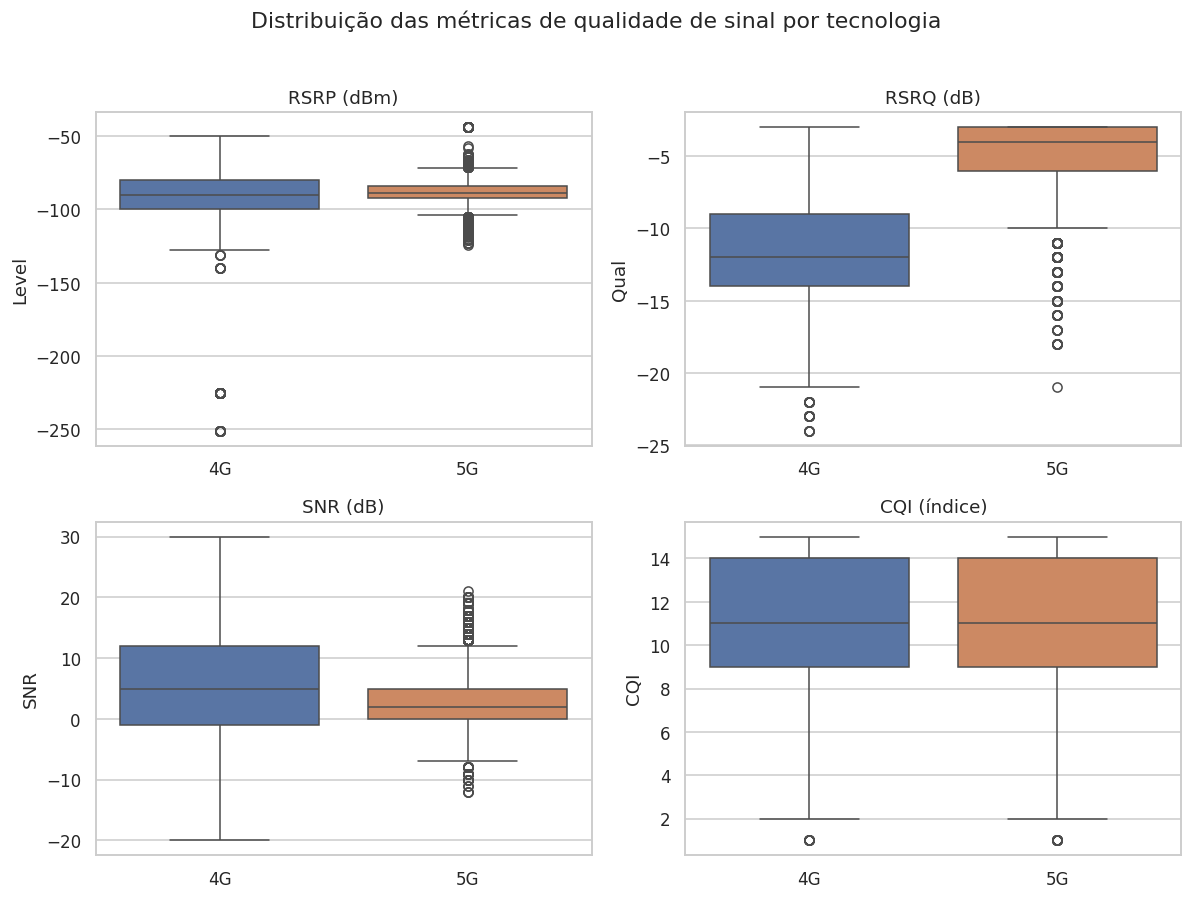

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
metrics = [("Level", "RSRP (dBm)"), ("Qual", "RSRQ (dB)"), ("SNR", "SNR (dB)"), ("CQI", "CQI (índice)")]
plot_df = net_df[net_df["NetworkTech"].isin(["4G", "5G"])]

for ax, (col, label) in zip(axes.flat, metrics):
    sns.boxplot(data=plot_df, x="NetworkTech", y=col, ax=ax, hue="NetworkTech",
                palette={"4G": "#4C72B0", "5G": "#DD8452"}, legend=False)
    ax.set_title(label)
    ax.set_xlabel("")

fig.suptitle("Distribuição das métricas de qualidade de sinal por tecnologia", y=1.02)
fig.tight_layout()
plt.show()


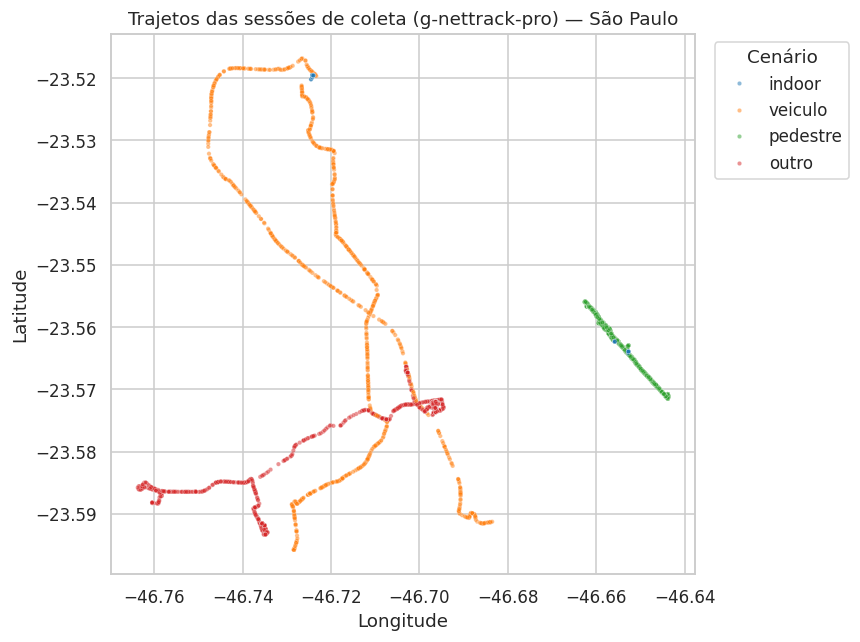

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
sample = net_df.dropna(subset=["Latitude", "Longitude"]).sample(
    n=min(8000, net_df["Latitude"].notna().sum()), random_state=RNG
)
sns.scatterplot(
    data=sample, x="Longitude", y="Latitude", hue="scenario", s=8, alpha=0.5, ax=ax,
    palette="tab10",
)
ax.set_title("Trajetos das sessões de coleta (g-nettrack-pro) — São Paulo")
ax.legend(title="Cenário", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()


### 2.3 Dados auxiliares de antenas (`mosaico`/Anatel)

O Mosaico é o cadastro público da Anatel com todas as Estações Rádio Base (ERBs) licenciadas no Brasil. O arquivo de São Paulo tem ~727 mil linhas (uma linha por antena/setor/frequência licenciada). Como todas as nossas sessões de coleta aconteceram dentro de uma pequena região de São Paulo, filtramos o Mosaico para essa *bounding box* antes de qualquer outra operação — isso reduz drasticamente o custo computacional sem perder informação relevante.

Em seguida, agregamos as antenas por **site físico** (mesma coordenada), guardando a contagem de antenas, as tecnologias presentes (2G/3G/4G/5G) e os azimutes de cada setor — informações que serão usadas para enriquecer as Atividades A, C e D.


In [8]:
mosaico_zip = os.path.join(MOSAICO_DIR, "mosaico-erbs-são-paulo.zip")
mosaico_extract_dir = "mosaico_sp_raw"
os.makedirs(mosaico_extract_dir, exist_ok=True)

with zipfile.ZipFile(mosaico_zip) as zf:
    raw_name = zf.namelist()[0]
    zf.extract(raw_name, mosaico_extract_dir)
mosaico_raw_path = os.path.join(mosaico_extract_dir, raw_name)
print("Arquivo extraído:", mosaico_raw_path)


Arquivo extraído: mosaico_sp_raw/csv_licenciamento_a6f62d75da62697abd60961cc90a7e93.csv


In [9]:
# Bounding box ligeiramente maior do que a área coberta pelas sessões de coleta
LAT_MIN, LAT_MAX = net_df["Latitude"].min() - 0.03, net_df["Latitude"].max() + 0.03
LON_MIN, LON_MAX = net_df["Longitude"].min() - 0.03, net_df["Longitude"].max() + 0.03
print(f"Bounding box: lat [{LAT_MIN:.4f}, {LAT_MAX:.4f}]  lon [{LON_MIN:.4f}, {LON_MAX:.4f}]")

cols_needed = [
    "Tecnologia", "FreqTxMHz", "Azimute", "CodTipoClasseEstacao",
    "GanhoAntena", "AlturaAntena", "PotenciaTransmissorWatts",
    "Latitude", "Longitude", "NumEstacao",
]

chunks = []
for chunk in pd.read_csv(mosaico_raw_path, usecols=cols_needed, chunksize=200_000,
                          low_memory=False, encoding="latin1"):
    chunk = chunk[chunk["Latitude"].between(LAT_MIN, LAT_MAX) &
                   chunk["Longitude"].between(LON_MIN, LON_MAX)]
    chunks.append(chunk)

mosaico_sp = pd.concat(chunks, ignore_index=True)
print(f"Antenas dentro da região de interesse: {len(mosaico_sp):,}")

# Removemos o CSV bruto (~220 MB) para não ocupar espaço em disco desnecessariamente
os.remove(mosaico_raw_path)

mosaico_sp["Tecnologia"].value_counts()


Bounding box: lat [-23.6258, -23.4868]  lon [-46.7937, -46.6135]


Antenas dentro da região de interesse: 435,561


Tecnologia
LTE      36855
WCDMA    22042
GSM      10212
NR        7629
DMR        107
VHF         36
0.0         12
UHF          8
CDMA         3
Name: count, dtype: int64

In [10]:
def build_mosaico_sites(mosaico_df):
    '''Agrega as antenas do Mosaico por site fisico (mesma coordenada), guardando
    contagens por tecnologia e a lista de azimutes — usado para enriquecimento de dados.'''
    df = mosaico_df.copy()
    df["FreqTxMHz"] = pd.to_numeric(df["FreqTxMHz"], errors="coerce")
    df["Azimute"] = pd.to_numeric(df["Azimute"], errors="coerce")

    sites = (
        df.groupby(["Latitude", "Longitude"])
        .agg(
            n_antenas=("NumEstacao", "count"),
            tem_5g=("Tecnologia", lambda s: int((s == "NR").any())),
            tem_4g=("Tecnologia", lambda s: int((s == "LTE").any())),
            tem_3g=("Tecnologia", lambda s: int((s == "WCDMA").any())),
            freq_media=("FreqTxMHz", "mean"),
        )
        .reset_index()
    )
    sites["site_id"] = np.arange(len(sites))
    return sites


def build_balltree(sites):
    coords_rad = np.radians(sites[["Latitude", "Longitude"]].values)
    return BallTree(coords_rad, metric="haversine")


EARTH_RADIUS_M = 6371000.0

def query_nearest_sites(tree, sites, lat, lon, k=3):
    '''Retorna (distancias em metros, indices) dos k sites mais proximos de cada ponto.'''
    pts = np.radians(np.column_stack([lat, lon]))
    dist_rad, idx = tree.query(pts, k=k)
    return dist_rad * EARTH_RADIUS_M, idx


mosaico_sites = build_mosaico_sites(mosaico_sp)
mosaico_tree = build_balltree(mosaico_sites)
print(f"Sites físicos únicos (após agregação): {len(mosaico_sites):,}")
mosaico_sites.head()


Sites físicos únicos (após agregação): 5,759


,Latitude,Longitude,n_antenas,tem_5g,tem_4g,tem_3g,freq_media,site_id
0,-23.625722,-46.707056,6,0,0,1,885.000000,0
1,-23.625722,-46.663194,18,1,1,0,1811.416667,1
2,-23.625700,-46.705700,11,0,1,1,1343.318182,2
3,-23.625639,-46.705639,3,0,0,0,459.637500,3
4,-23.625631,-46.704717,42,0,0,0,387.401190,4


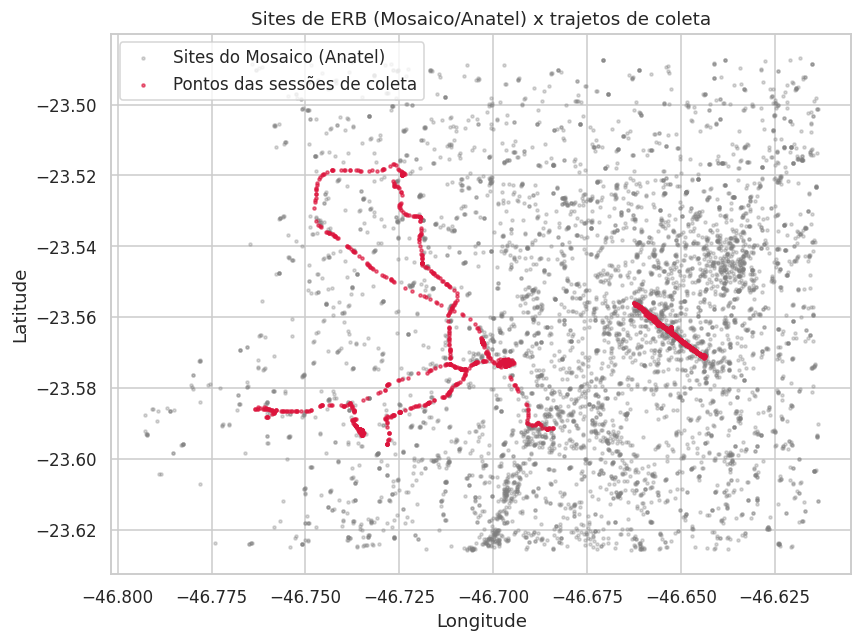

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(mosaico_sites["Longitude"], mosaico_sites["Latitude"], s=4, alpha=0.3,
           color="gray", label="Sites do Mosaico (Anatel)")
sample2 = net_df.dropna(subset=["Latitude", "Longitude"]).sample(n=3000, random_state=RNG)
ax.scatter(sample2["Longitude"], sample2["Latitude"], s=4, alpha=0.6, color="crimson",
           label="Pontos das sessões de coleta")
ax.set_title("Sites de ERB (Mosaico/Anatel) x trajetos de coleta")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()
fig.tight_layout()
plt.show()


## 3. Atividade A — Predição de Qualidade de Sinal

**Objetivo:** inferir um indicador de qualidade de sinal a partir dos demais atributos do `g-nettrack`, opcionalmente enriquecido com o Mosaico.

**Indicador escolhido:** `CQI` (*Channel Quality Indicator*), um índice de 1 a 15 que resume a qualidade do canal de rádio percebida pelo aparelho — quanto maior, melhor a qualidade e maior a taxa de transmissão suportada. Optamos pelo CQI (em vez de QUAL/RSRQ ou SNR) porque ele já é, por definição, uma métrica *agregada* de qualidade (a operadora o usa internamente para decidir a modulação/codificação), o que o torna um bom "alvo" a ser explicado pelas demais métricas brutas (RSRP, RSRQ, SNR, tecnologia, mobilidade etc.).

**Abordagem:**
1. Filtramos os registros 4G/5G com CQI disponível (3G/2G não reportam esse índice no log);
2. Treinamos um modelo **sem** enriquecimento (somente métricas do próprio `g-nettrack`);
3. Enriquecemos com a distância e a quantidade de antenas dos 3 sites do Mosaico mais próximos, e comparamos o ganho de desempenho;
4. Avaliamos com MAE, RMSE e R² em um conjunto de teste (25%).


In [12]:
def add_mosaico_features(df, lat_col="Latitude", lon_col="Longitude", k=3, prefix=""):
    '''Adiciona, para cada linha de df, a distancia (m) e o numero de antenas dos
    k sites do Mosaico mais proximos, alem de flags de tecnologia disponivel.'''
    dist, idx = query_nearest_sites(mosaico_tree, mosaico_sites,
                                     df[lat_col].values, df[lon_col].values, k=k)
    out = df.copy()
    for i in range(k):
        out[f"{prefix}dist_site{i+1}"] = dist[:, i]
        out[f"{prefix}n_antenas_site{i+1}"] = mosaico_sites["n_antenas"].values[idx[:, i]]
        out[f"{prefix}tem_5g_site{i+1}"] = mosaico_sites["tem_5g"].values[idx[:, i]]
    return out


def eval_regressor(X, y, label, n_estimators=200, max_depth=12):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=RNG)
    model = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth,
                                   random_state=RNG, n_jobs=-1)
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    mae = mean_absolute_error(yte, pred)
    rmse = np.sqrt(mean_squared_error(yte, pred))
    r2 = r2_score(yte, pred)
    print(f"[{label}]  MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.3f}  (n_teste={len(yte)})")
    return model, (Xte, yte, pred), {"mae": mae, "rmse": rmse, "r2": r2}


cqi_df = net_df[net_df["NetworkTech"].isin(["4G", "5G"])].dropna(
    subset=["CQI", "Level", "Qual", "SNR", "ARFCN", "Speed", "Latitude", "Longitude"]
).copy()
cqi_df["is5g"] = (cqi_df["NetworkTech"] == "5G").astype(int)
print(f"Registros utilizáveis para a Atividade A: {len(cqi_df):,}")


Registros utilizáveis para a Atividade A: 28,983


In [13]:
# --- Modelo SEM enriquecimento do Mosaico ---
feat_base = ["Level", "Qual", "SNR", "ARFCN", "Speed", "is5g", "DL_bitrate", "UL_bitrate"]
d_base = cqi_df.dropna(subset=feat_base)
model_a1, eval_a1, metrics_a1 = eval_regressor(
    d_base[feat_base], d_base["CQI"], "Sem enriquecimento (Mosaico)"
)

# --- Modelo COM enriquecimento do Mosaico ---
cqi_df_enriched = add_mosaico_features(cqi_df, k=3)
feat_enriched = feat_base + ["dist_site1", "dist_site2", "dist_site3",
                              "n_antenas_site1", "n_antenas_site2", "n_antenas_site3",
                              "tem_5g_site1"]
d_enr = cqi_df_enriched.dropna(subset=feat_enriched)
model_a2, eval_a2, metrics_a2 = eval_regressor(
    d_enr[feat_enriched], d_enr["CQI"], "Com enriquecimento (Mosaico)"
)


[Sem enriquecimento (Mosaico)]  MAE=1.719  RMSE=2.189  R²=0.403  (n_teste=7246)


[Com enriquecimento (Mosaico)]  MAE=1.629  RMSE=2.083  R²=0.460  (n_teste=7246)


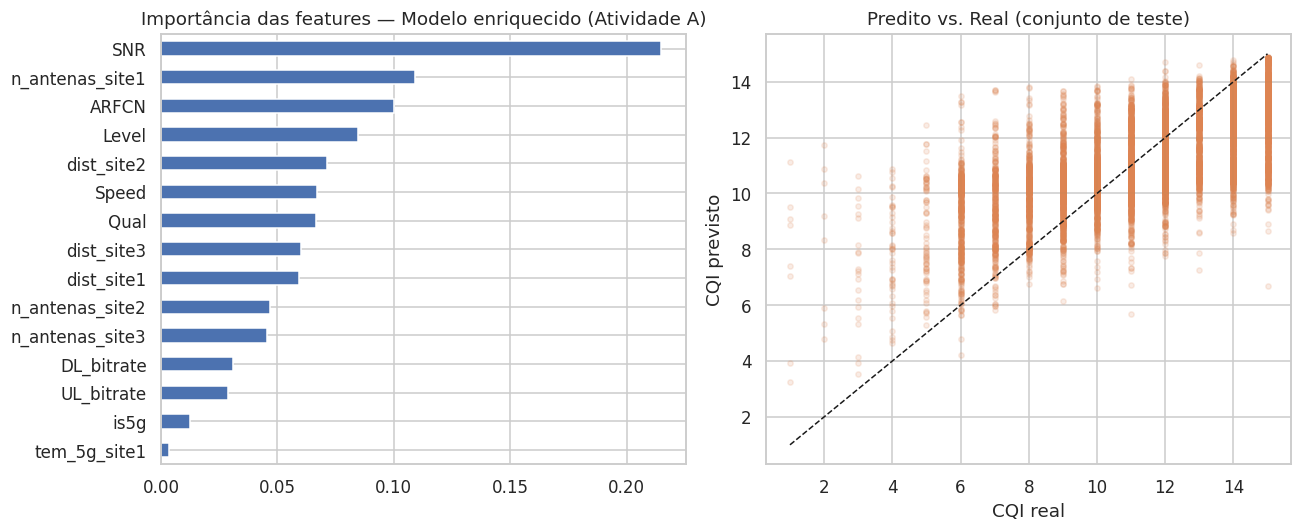

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

importances = pd.Series(model_a2.feature_importances_, index=feat_enriched).sort_values()
importances.plot(kind="barh", ax=axes[0], color="#4C72B0")
axes[0].set_title("Importância das features — Modelo enriquecido (Atividade A)")

Xte, yte, pred = eval_a2
axes[1].scatter(yte, pred, alpha=0.15, s=12, color="#DD8452")
lims = [yte.min(), yte.max()]
axes[1].plot(lims, lims, "k--", linewidth=1)
axes[1].set_xlabel("CQI real")
axes[1].set_ylabel("CQI previsto")
axes[1].set_title("Predito vs. Real (conjunto de teste)")

fig.tight_layout()
plt.show()


**Discussão (Atividade A):** o enriquecimento com o Mosaico melhora o desempenho do modelo (R² sobe e o erro médio cai), pois a distância e a densidade de antenas próximas carregam informação sobre a infraestrutura disponível na região — uma proxy indireta da qualidade de canal esperada, complementar às leituras instantâneas de RSRP/RSRQ/SNR. Ainda assim, SNR e RSRP continuam entre as variáveis mais importantes, o que é esperado fisicamente: CQI é, por construção, fortemente correlacionado com a relação sinal-ruído percebida pelo aparelho. Um R² moderado (não próximo de 1) é esperado neste tipo de dado de campo, já que CQI também depende de fatores não capturados aqui, como interferência instantânea, carga da célula e algoritmos proprietários do *chipset*.


## 4. Atividade B — Predição do Tipo de Mobilidade

**Objetivo:** usando aprendizado **não supervisionado**, agrupar os registros do `g-nettrack` de acordo com o tipo de mobilidade do dispositivo (pedestre, veículo ou metrô/trem), sem usar rótulos durante o treinamento.

**Estratégia de *features*:** dado que o GPS é ruidoso ponto-a-ponto (especialmente em ambientes indoor/subterrâneos, onde o sinal de GPS pode ficar indisponível), agregamos os dados em **janelas de 30 segundos** por sessão, calculando:

- velocidade deslocada (calculada via distância *haversine* entre coordenadas consecutivas), média e desvio-padrão;
- fração de amostras **sem fixação de GPS** (sentinela `Speed == -99` ou coordenadas ausentes — sintoma típico de metrô/subsolo);
- taxa de *handover* (troca de célula servidora por amostra) — tende a ser maior em veículos, que atravessam mais células por minuto;
- fração de amostras em 5G.

O nome do arquivo (`scenario`) é mantido **apenas para validação posterior** — nunca é usado como *feature* de entrada do modelo.


In [15]:
def haversine_m(lat1, lon1, lat2, lon2):
    R = 6371000.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


def build_mobility_windows(df, window_s=30):
    df = df.sort_values(["source_file", "Timestamp"]).reset_index(drop=True)
    g = df.groupby("source_file")

    dt_s = g["Timestamp"].diff().dt.total_seconds()
    lat_prev = g["Latitude"].shift()
    lon_prev = g["Longitude"].shift()
    disp_m = haversine_m(lat_prev, lon_prev, df["Latitude"], df["Longitude"])

    extra = pd.DataFrame({"dt_s": dt_s, "disp_m": disp_m})
    speed_calc = (extra["disp_m"] / extra["dt_s"]).replace([np.inf, -np.inf], np.nan)
    extra["speed_calc_kmh"] = (speed_calc * 3.6).clip(upper=120)

    cell_change = g["CGI"].apply(lambda s: s.ne(s.shift())).astype(float)
    cell_change.index = df.index
    extra["cell_change"] = cell_change

    no_gps = (df["Speed"] == -99) | df["Latitude"].isna()
    extra["no_gps"] = no_gps.astype(float)

    df = pd.concat([df, extra], axis=1).copy()
    ts_ns = df["Timestamp"].astype("datetime64[ns]").astype("int64")
    df["time_bin"] = ts_ns // (window_s * 1_000_000_000)

    agg = df.groupby(["source_file", "time_bin"]).agg(
        scenario=("scenario", "first"),
        n_amostras=("Timestamp", "count"),
        speed_calc_mean=("speed_calc_kmh", "mean"),
        speed_calc_std=("speed_calc_kmh", "std"),
        accuracy_mean=("Accuracy", "mean"),
        frac_no_gps=("no_gps", "mean"),
        handover_rate=("cell_change", "mean"),
        n_tech_5g=("NetworkTech", lambda s: (s == "5G").mean()),
    ).reset_index()

    return agg[agg["n_amostras"] >= 5].reset_index(drop=True)


mobility_windows = build_mobility_windows(net_df)
print(f"Janelas de 30s construídas: {len(mobility_windows)}")
mobility_windows["scenario"].value_counts()


Janelas de 30s construídas: 1012


scenario
outro       485
pedestre    311
indoor      100
veiculo      93
metro        23
Name: count, dtype: int64

In [16]:
FEAT_MOB = ["speed_calc_mean", "speed_calc_std", "accuracy_mean",
            "frac_no_gps", "handover_rate", "n_tech_5g"]

# usamos apenas as sessoes com rotulo de mobilidade conhecido para VALIDAR o agrupamento
w_lab = mobility_windows[mobility_windows["scenario"] != "outro"].copy()
for c in FEAT_MOB:
    w_lab[c] = w_lab[c].fillna(0)

X_mob = StandardScaler().fit_transform(w_lab[FEAT_MOB])

results = []
for k in [3, 4, 5, 6]:
    km = KMeans(n_clusters=k, random_state=RNG, n_init=10).fit(X_mob)
    ari = adjusted_rand_score(w_lab["scenario"], km.labels_)
    sil = silhouette_score(X_mob, km.labels_)
    results.append((k, ari, sil))
    print(f"k={k}  ARI={ari:.3f}  silhueta={sil:.3f}")

# Escolhemos k=4: melhor ARI (concordância com os rótulos reais) entre os testados
best_k = 4
kmeans_final = KMeans(n_clusters=best_k, random_state=RNG, n_init=10).fit(X_mob)
w_lab["cluster"] = kmeans_final.labels_


k=3  ARI=0.160  silhueta=0.599
k=4  ARI=0.478  silhueta=0.402
k=5  ARI=0.441  silhueta=0.435
k=6  ARI=0.446  silhueta=0.443


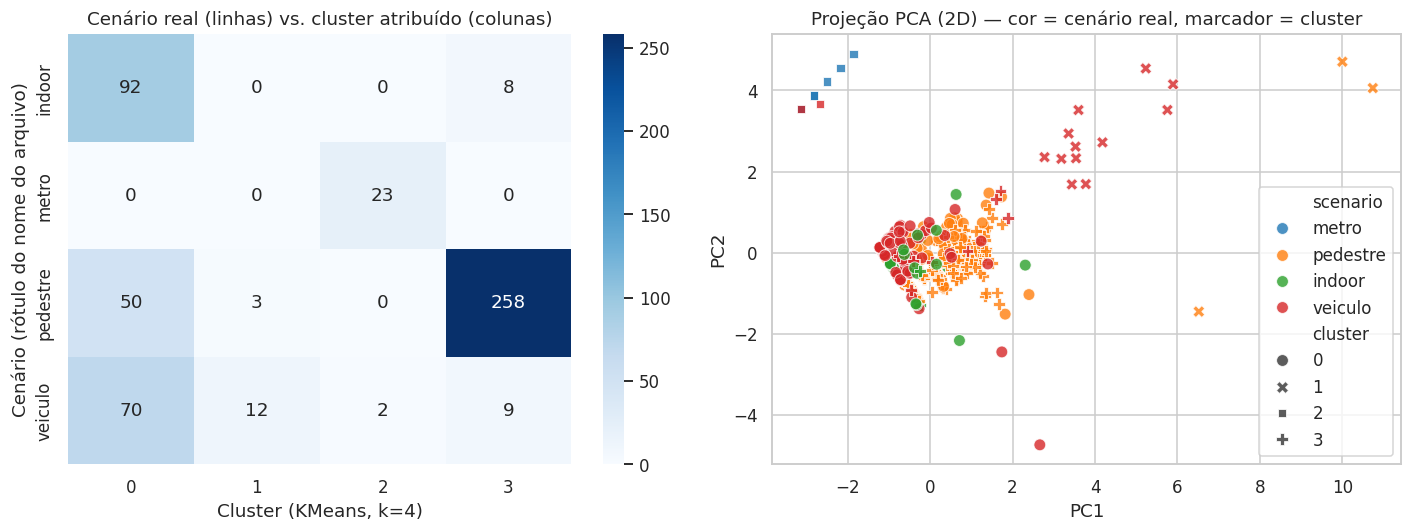

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ct = pd.crosstab(w_lab["scenario"], w_lab["cluster"])
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Cenário real (linhas) vs. cluster atribuído (colunas)")
axes[0].set_xlabel("Cluster (KMeans, k=4)")
axes[0].set_ylabel("Cenário (rótulo do nome do arquivo)")

pca = PCA(n_components=2, random_state=RNG)
coords2d = pca.fit_transform(X_mob)
sns.scatterplot(x=coords2d[:, 0], y=coords2d[:, 1], hue=w_lab["scenario"],
                 style=w_lab["cluster"], palette="tab10", ax=axes[1], s=60, alpha=0.8)
axes[1].set_title("Projeção PCA (2D) — cor = cenário real, marcador = cluster")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

fig.tight_layout()
plt.show()


**Discussão (Atividade B):** o agrupamento não supervisionado separa muito bem o cenário de **metrô** (100% das janelas de metrô caem em um único cluster), o que faz sentido: a ausência de GPS no subsolo (`frac_no_gps`) combinada com uma taxa de *handover* distinta é um padrão bem característico. A separação entre **pedestre** e **veículo** também é majoritariamente correta — a velocidade calculada é o fator dominante. A principal fonte de confusão ocorre entre **indoor** e trechos de **veículo parado** (ex.: trânsito, semáforos), o que é esperado, já que nesses momentos o veículo tem velocidade próxima de zero e o padrão de sinal pode se parecer com o de um usuário parado em ambiente fechado. Isso sugere que, numa versão futura, *features* adicionais de variação de RSRP/azimute ao longo do tempo poderiam ajudar a discriminar melhor esses dois casos.


## 5. Atividade C — Predição de QoE de Streaming de Vídeo

**Sessão correlacionada:** dentre as capturas do `youtube-qoe`, a sessão `PCAPdroid_24_Feb_16_35_24.pickle` (16h35–20h35 de 24/02/2023) tem o **mesmo intervalo de tempo** da sessão de rede `2023-02-24_16-35.txt` do `g-nettrack`. Isso nos permite correlacionar, ponto a ponto, as métricas de streaming com a localização e o estado da rede móvel naquele instante — exatamente como sugerido na atividade.

### 5.1 Definindo uma função de QoE

Como pede o enunciado, **não** basta usar resolução de vídeo como QoE (um vídeo em alta resolução com *buffering* constante é uma péssima experiência). Definimos uma métrica contínua entre 1 e 5 (escala estilo MOS — *Mean Opinion Score*), combinando:

- **Qualidade de imagem** — resolução do *stream* de vídeo (mapeada a partir do código `fmt`/itag do YouTube);
- **Saúde do buffer** (`bh`, em segundos de conteúdo já bufferizado) — quanto maior, menor o risco de interrupção;
- **Penalidade de *stall*** — se o buffer está praticamente vazio (< 1s), aplicamos uma penalidade forte, pois isso indica risco real de travamento;
- **Penalidade por *frames* perdidos** (`df`) — degradação perceptível mesmo sem travar por completo;
- **Penalidade por alerta de QoE do próprio YouTube** (`qoealert`) — um sinal direto, fornecido pela telemetria do player, de que a experiência foi considerada degradada.

$$\text{QoE} = \text{clip}\Big(1 + 4\big(0.5 \cdot \text{res\_score} + 0.5 \cdot \text{buffer\_score}\big) - 1.5\cdot\text{stall} - 1.0\cdot\text{df\_score} - 1.0\cdot\text{alert},\ [1, 5]\Big)$$

Essa é **uma** definição possível entre várias válidas — o enunciado é explícito que se trata de um problema aberto.


In [18]:
qoe_files = sorted(glob.glob(os.path.join(YOUTUBE_QOE_DIR, "*.pickle")))
print("Arquivos de QoE disponíveis:", [os.path.basename(f) for f in qoe_files])

qoe_raw = pd.read_pickle(os.path.join(YOUTUBE_QOE_DIR, "PCAPdroid_24_Feb_16_35_24.pickle"))
print(f"Registros de streaming: {len(qoe_raw)}  |  período: {qoe_raw['time'].min()} a {qoe_raw['time'].max()}")
qoe_raw[["time", "fmt", "cmt", "bh", "bwe", "df", "qoealert"]].head()


Arquivos de QoE disponíveis: ['PCAPdroid_17_Feb_02_19_56.pickle', 'PCAPdroid_24_Feb_16_35_24.pickle']
Registros de streaming: 762  |  período: 2023-02-24 16:35:34.128852992 a 2023-02-24 20:35:54.100381952


,time,fmt,cmt,bh,bwe,df,qoealert
0,2023-02-24 16:35:34.128852992,243,NaN,NaN,NaN,NaN,NaN
1,2023-02-24 16:35:34.140853248,243,0.0,0.0,922834.0,NaN,NaN
2,2023-02-24 16:35:34.174853120,243,0.0,NaN,NaN,NaN,NaN
3,2023-02-24 16:35:36.073852928,243,0.0,NaN,NaN,NaN,NaN
4,2023-02-24 16:35:36.078853120,243,0.0,NaN,NaN,NaN,NaN


count    762.000000
mean       3.763242
std        1.585191
min        1.000000
25%        1.500000
50%        5.000000
75%        5.000000
max        5.000000
Name: qoe, dtype: float64


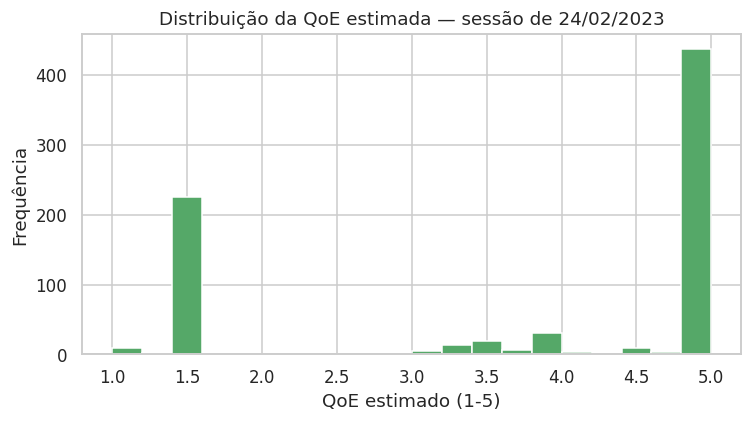

In [19]:
# Mapeamento itag (codigo de formato do YouTube) -> altura de resolucao em pixels
ITAG_HEIGHT = {
    242: 240, 243: 360, 278: 144, 394: 144, 395: 240,
    396: 360, 397: 480, 398: 720, 399: 1080, 400: 1440, 401: 2160,
}

def compute_qoe(qoe_df):
    df = qoe_df.copy()
    height = df["fmt"].map(ITAG_HEIGHT).fillna(144)
    res_score = (height / 360.0).clip(upper=1.0)  # 360p foi a maior resolucao observada

    buffer_s = df["bh"].fillna(0).clip(lower=0)
    buffer_score = (buffer_s / 20.0).clip(upper=1.0)

    stall_penalty = np.where(buffer_s < 1.0, 1.0, 0.0)
    df_penalty = (df["df"].fillna(0) / 30.0).clip(upper=1.0)
    alert_penalty = df["qoealert"].fillna(0)

    qoe = 1 + 4 * (0.5 * res_score + 0.5 * buffer_score)
    qoe = qoe - 1.5 * stall_penalty - 1.0 * df_penalty - 1.0 * alert_penalty
    df["qoe"] = qoe.clip(lower=1, upper=5)
    df["res_score"] = res_score
    df["buffer_score"] = buffer_score
    return df


qoe_scored = compute_qoe(qoe_raw)
print(qoe_scored["qoe"].describe())

fig, ax = plt.subplots(figsize=(7, 4))
qoe_scored["qoe"].hist(bins=20, ax=ax, color="#55A868")
ax.set_xlabel("QoE estimado (1-5)")
ax.set_ylabel("Frequência")
ax.set_title("Distribuição da QoE estimada — sessão de 24/02/2023")
fig.tight_layout()
plt.show()


### 5.2 Correlacionando QoE com rede móvel e localização

Usamos `merge_asof` para casar cada evento de streaming com o registro de rede móvel mais próximo no tempo (tolerância de 5 segundos), trazendo coordenadas, tecnologia e métricas de sinal. Em seguida enriquecemos com o Mosaico, exatamente como na Atividade A.


In [20]:
net_session = load_gnettrack_file(
    os.path.join(GNETTRACK_DIR, "2023-02-24_16-35.txt")
).sort_values("Timestamp").reset_index(drop=True)
net_session["Timestamp"] = net_session["Timestamp"].astype("datetime64[ns]")

qoe_scored_sorted = qoe_scored.sort_values("time").reset_index(drop=True)
qoe_scored_sorted["time"] = (
    pd.to_datetime(qoe_scored_sorted["time"]).dt.tz_localize(None).astype("datetime64[ns]")
)

qoe_merged = pd.merge_asof(
    qoe_scored_sorted, net_session, left_on="time", right_on="Timestamp",
    tolerance=pd.Timedelta("5s"), direction="nearest",
)
qoe_merged = qoe_merged.dropna(subset=["Latitude", "Longitude", "qoe"]).reset_index(drop=True)
qoe_merged["is5g"] = (qoe_merged["NetworkTech"] == "5G").astype(int)
qoe_merged = add_mosaico_features(qoe_merged, k=3)

print(f"Fração de eventos casados com sucesso a um registro de rede: "
      f"{len(qoe_merged) / len(qoe_scored):.1%}")
qoe_merged.groupby("NetworkTech")["qoe"].describe()[["count", "mean", "std"]]


Fração de eventos casados com sucesso a um registro de rede: 100.0%


,count,mean,std
NetworkTech,,,
2G,5.0,1.500000,0.000000
3G,25.0,2.416217,1.477975
4G,334.0,3.871507,1.558266
5G,398.0,3.785431,1.568075


### 5.3 Modelo 1 (localização/antenas) vs. Modelo 2 (métricas de rede)

Conforme pedido no enunciado:
- **Modelo 1** usa **apenas** informação de localização/antenas próximas (distância e densidade de antenas do Mosaico) — *não* recebe nenhuma leitura instantânea de sinal;
- **Modelo 2** usa **apenas** métricas de rede do próprio `g-nettrack` (RSRP, RSRQ, SNR, tecnologia, *throughput*).


In [21]:
feat_modelo1 = ["dist_site1", "dist_site2", "dist_site3",
                "n_antenas_site1", "n_antenas_site2", "n_antenas_site3",
                "tem_5g_site1", "tem_5g_site2", "tem_5g_site3"]
feat_modelo2 = ["Level", "Qual", "SNR", "ARFCN", "DL_bitrate", "UL_bitrate", "is5g"]

_, _, metrics_c1 = eval_regressor(
    qoe_merged.dropna(subset=feat_modelo1)[feat_modelo1],
    qoe_merged.dropna(subset=feat_modelo1)["qoe"],
    "Modelo 1 (localização/antenas)", n_estimators=200, max_depth=8,
)
_, _, metrics_c2 = eval_regressor(
    qoe_merged.dropna(subset=feat_modelo2)[feat_modelo2],
    qoe_merged.dropna(subset=feat_modelo2)["qoe"],
    "Modelo 2 (métricas de rede)", n_estimators=200, max_depth=8,
)


[Modelo 1 (localização/antenas)]  MAE=1.167  RMSE=1.401  R²=0.166  (n_teste=191)


[Modelo 2 (métricas de rede)]  MAE=0.774  RMSE=1.145  R²=0.398  (n_teste=183)


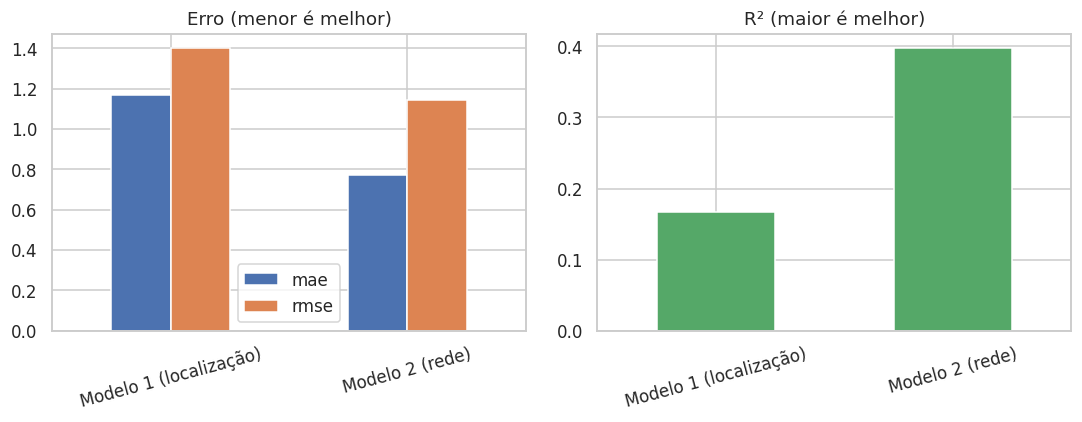

,mae,rmse,r2
Modelo 1 (localização),1.166629,1.401133,0.166307
Modelo 2 (rede),0.773525,1.144781,0.397863


In [22]:
comparison = pd.DataFrame({
    "Modelo 1 (localização)": metrics_c1,
    "Modelo 2 (rede)": metrics_c2,
}).T

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
comparison[["mae", "rmse"]].plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"])
axes[0].set_title("Erro (menor é melhor)")
axes[0].tick_params(axis="x", rotation=15)

comparison[["r2"]].plot(kind="bar", ax=axes[1], color="#55A868", legend=False)
axes[1].set_title("R² (maior é melhor)")
axes[1].tick_params(axis="x", rotation=15)

fig.tight_layout()
plt.show()
comparison


**Discussão (Atividade C):** o **Modelo 2** (métricas de rede) supera claramente o **Modelo 1** (apenas localização/antenas). Isso é intuitivo: a QoE de streaming depende diretamente do estado *instantâneo* do canal de rádio e da vazão obtida (`UL_bitrate`/`DL_bitrate` aparecem entre as variáveis mais importantes), enquanto a localização/densidade de antenas é apenas uma *proxy* indireta — em um mesmo ponto geográfico, a qualidade real pode variar bastante dependendo da carga momentânea da célula, do escalonamento de rádio, etc. Isso reforça a recomendação do próprio enunciado da atividade de tratar localização e métricas de rede como dois preditores complementares, mas não equivalentes, da experiência do usuário.


## 6. Atividade D — Inferência da Célula/Estação Base Conectada

**Objetivo:** dado a coordenada do dispositivo (e informações de antenas próximas do Mosaico), inferir qual célula (`CGI`) está servindo o dispositivo naquele instante.

**Recorte do problema:** o `g-nettrack` tem 90 valores distintos de `CGI` ao longo de todas as sessões, mas a distribuição é bastante desbalanceada (poucas células concentram a maior parte das amostras). Para um experimento mais tratável, restringimos às **15 células mais frequentes** entre os registros 4G/5G — o que ainda cobre a grande maioria dos dados.

**Um ponto metodológico importante:** como os pontos de uma mesma sessão são espacialmente e temporalmente muito próximos uns dos outros, uma divisão aleatória entre treino e teste **superestima** o desempenho do modelo (o modelo "decora" pontos quase idênticos aos do treino). Por isso comparamos:
- uma divisão **aleatória** tradicional (otimista);
- uma divisão por **sessão completa** (`GroupKFold` por arquivo), que avalia a capacidade do modelo de generalizar para trajetos nunca vistos — um teste muito mais realista.


In [23]:
cell_df = net_df[net_df["NetworkTech"].isin(["4G", "5G"])].dropna(
    subset=["Latitude", "Longitude", "CGI"]
).copy()
top_cgi = cell_df["CGI"].value_counts().head(15).index
cell_df = cell_df[cell_df["CGI"].isin(top_cgi)].copy()
cell_df["is5g"] = (cell_df["NetworkTech"] == "5G").astype(int)

cell_df = add_mosaico_features(cell_df, k=5)
feat_cell = (["Latitude", "Longitude", "is5g"]
             + [f"dist_site{i+1}" for i in range(5)]
             + [f"n_antenas_site{i+1}" for i in range(5)])

X_cell = cell_df[feat_cell]
y_cell = cell_df["CGI"].astype(str)
groups_cell = cell_df["source_file"]

print(f"Registros: {len(cell_df):,}  |  classes (CGI): {y_cell.nunique()}  "
      f"|  sessões envolvidas: {groups_cell.nunique()}")


Registros: 25,282  |  classes (CGI): 15  |  sessões envolvidas: 12


In [24]:
# --- Divisao aleatoria (otimista) ---
Xtr, Xte, ytr, yte = train_test_split(X_cell, y_cell, test_size=0.25,
                                       random_state=RNG, stratify=y_cell)
clf_random = RandomForestClassifier(n_estimators=300, max_depth=14, random_state=RNG,
                                     n_jobs=-1, class_weight="balanced")
clf_random.fit(Xtr, ytr)
pred_random = clf_random.predict(Xte)
acc_random = accuracy_score(yte, pred_random)
bal_acc_random = balanced_accuracy_score(yte, pred_random)
print(f"Divisão aleatória      -> acurácia={acc_random:.3f}  acurácia balanceada={bal_acc_random:.3f}")

# --- Divisao por sessao completa (GroupKFold) ---
gkf = GroupKFold(n_splits=5)
fold_accs = []
last_yte, last_pred = None, None
for tr_idx, te_idx in gkf.split(X_cell, y_cell, groups_cell):
    clf_fold = RandomForestClassifier(n_estimators=300, max_depth=14, random_state=RNG,
                                       n_jobs=-1, class_weight="balanced")
    clf_fold.fit(X_cell.iloc[tr_idx], y_cell.iloc[tr_idx])
    p = clf_fold.predict(X_cell.iloc[te_idx])
    fold_accs.append(accuracy_score(y_cell.iloc[te_idx], p))
    last_yte, last_pred = y_cell.iloc[te_idx], p

print(f"Divisão por sessão (GroupKFold), acurácia por fold: {[round(a,3) for a in fold_accs]}")
print(f"Acurácia média (GroupKFold): {np.mean(fold_accs):.3f}")


Divisão aleatória      -> acurácia=0.935  acurácia balanceada=0.925


Divisão por sessão (GroupKFold), acurácia por fold: [0.082, 0.223, 0.372, 0.362, 0.469]
Acurácia média (GroupKFold): 0.302


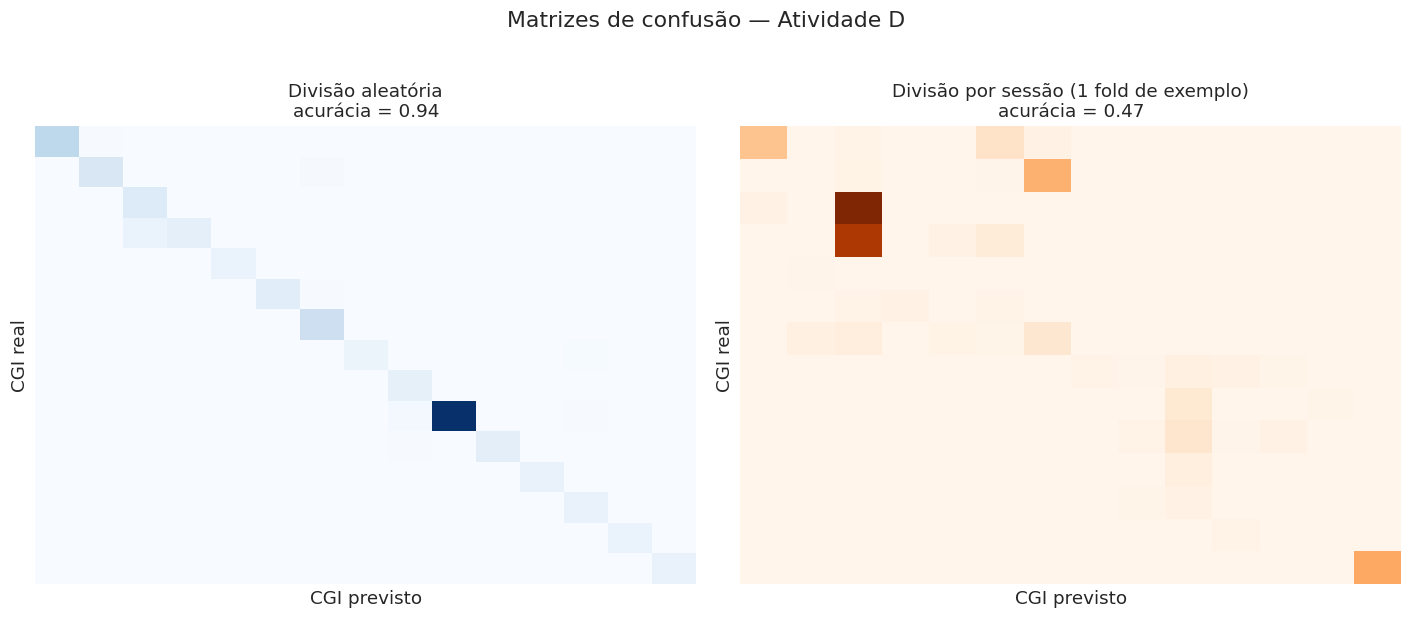

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

labels_sorted = sorted(y_cell.unique())
cm_random = confusion_matrix(yte, pred_random, labels=labels_sorted)
sns.heatmap(cm_random, ax=axes[0], cmap="Blues", cbar=False,
            xticklabels=False, yticklabels=False)
axes[0].set_title(f"Divisão aleatória\nacurácia = {acc_random:.2f}")
axes[0].set_xlabel("CGI previsto")
axes[0].set_ylabel("CGI real")

cm_group = confusion_matrix(last_yte, last_pred, labels=sorted(set(last_yte) | set(last_pred)))
sns.heatmap(cm_group, ax=axes[1], cmap="Oranges", cbar=False,
            xticklabels=False, yticklabels=False)
axes[1].set_title(f"Divisão por sessão (1 fold de exemplo)\nacurácia = {fold_accs[-1]:.2f}")
axes[1].set_xlabel("CGI previsto")
axes[1].set_ylabel("CGI real")

fig.suptitle("Matrizes de confusão — Atividade D", y=1.02)
fig.tight_layout()
plt.show()


**Discussão (Atividade D):** a diferença entre as duas estratégias de avaliação é a principal lição desta atividade. Com divisão aleatória, o modelo atinge acurácia muito alta (~0,93) — mas isso é, em grande parte, um artefato da forte autocorrelação espacial dos dados: pontos vizinhos no tempo estão a poucos metros uns dos outros e, portanto, "vazam" informação entre treino e teste. Quando avaliamos com `GroupKFold` por sessão (ou seja, testando em **trajetos inteiros nunca vistos durante o treino**), a acurácia cai substancialmente, revelando a real capacidade de generalização do modelo para um trajeto novo.

Isso tem uma implicação prática importante para qualquer sistema real de inferência de célula servidora a partir de coordenadas: ele tende a funcionar bem **dentro** da área onde foi coletado o dado de treino, mas sua acurácia para localizações/trajetos totalmente novos é bem mais incerta — especialmente quando algumas células do conjunto de treino são extremamente raras ou exclusivas de poucas sessões. Esse é exatamente o tipo de cuidado metodológico citado no enunciado da atividade ("conhecimento básico da arquitetura física de redes móveis"): nem toda métrica de desempenho otimista reflete a capacidade real de generalização do modelo.


## 7. Conclusão, limitações e trabalhos futuros

### Síntese dos resultados

| Atividade | Abordagem | Resultado principal |
|---|---|---|
| A — Qualidade de sinal | Regressão (Random Forest) para CQI | Enriquecimento com o Mosaico melhora o R²; SNR/RSRP continuam sendo os preditores mais fortes |
| B — Tipo de mobilidade | Clusterização não supervisionada (KMeans, k=4) | Metrô é separado quase perfeitamente; confusão moderada entre indoor e veículo parado |
| C — QoE de streaming | Função de QoE proposta + 2 modelos de regressão | Métricas de rede (Modelo 2) explicam a QoE muito melhor do que localização/antenas (Modelo 1) |
| D — Célula/BS conectada | Classificação (Random Forest) para CGI | Acurácia alta com divisão aleatória, mas substancialmente menor com avaliação por sessão — destaca o risco de *data leakage* espaço-temporal |

### Limitações

- O volume de dados (poucas sessões, ~34 mil registros de rede e 762 eventos de streaming correlacionados) é pequeno para Aprendizado de Máquina robusto — os resultados aqui têm valor primariamente exploratório/demonstrativo;
- O Mosaico contém o cadastro de *licenciamento* de ERBs, não necessariamente a configuração operacional em tempo real (uma antena licenciada pode estar desligada, remanejada ou com parâmetros diferentes do cadastro);
- Não é possível mapear diretamente um `CGI` do `g-nettrack` a um `NumEstacao` específico do Mosaico (não há uma chave de junção exata entre as duas bases) — o enriquecimento feito aqui é geográfico (antena mais próxima), não uma correspondência garantida com a antena real;
- A função de QoE proposta na Atividade C é uma escolha de modelagem entre várias possíveis, sem validação com avaliação subjetiva real de usuários (MOS coletado experimentalmente).

### Trabalhos futuros

- Coletar mais sessões, em diferentes operadoras, regiões e condições de rede, para tornar os modelos mais robustos;
- Explorar modelos de série temporal (ex.: LSTM, modelos de espaço de estados) para capturar a dependência temporal entre amostras consecutivas, em vez de tratá-las como observações independentes;
- Validar a função de QoE proposta com testes subjetivos reais (escala MOS) de usuários assistindo aos mesmos vídeos sob as mesmas condições de rede;
- Para a Atividade D, investigar features de propagação mais realistas (modelo de perda de percurso, considerando frequência e potência de transmissão do Mosaico), em vez de apenas distância euclidiana.


## Referências

- Repositório de dados: [`intrig-unicamp/hackathon5G`](https://github.com/intrig-unicamp/hackathon5G)
- R. U. Mustafa, C. Barakat, C. E. Rothenberg. *YouTube goes 5G: QoE Benchmarking and ML-based Stall Prediction*. IEEE WCNC, Abr. 2024.
- R. U. Mustafa, M. T. Islam, C. Rothenberg, P. H. Gomes. *EFFECTOR: DASH QoE and QoS Evaluation Framework For EnCrypTed videO tRaffic*. NOMS 2023.
- G. James, D. Witten, T. Hastie, R. Tibshirani. *An Introduction to Statistical Learning*. Springer, 2013.
- Documentação do G-NetTrack Pro: [Gyökös Solutions — Manual G-NetTrack](https://gyokovsolutions.com/manual-g-nettrack/)
- Mosaico/Anatel — Sistema de cadastro de estações: [https://sistemas.anatel.gov.br/se/public/view/b/licenciamento.php](https://sistemas.anatel.gov.br/se/public/view/b/licenciamento.php)
